In [ ]:
def model(w, x):
  y_pred = w * x
  return y_pred

In [ ]:
y_pred = model(1, 1)

1

In [ ]:
loss_1 = (y_pred - 2) ** 2

In [ ]:
y_pred = model(1, 2)

In [ ]:
loss_2 = (y_pred - 4) ** 2

In [ ]:
# --- 「一括展開」ルートのコード ---
w = 0.0
lr = 0.1

for epoch in range(5):
    # ★ポイント：データの中身は見ない。
    # すでに計算済みの「全体の勾配」の式をそのまま使う。
    mean_grad = 5 * w - 10

    # 更新
    w = w - lr * mean_grad

    print(f"Epoch {epoch+1}: w = {w:.4f}, Grad = {mean_grad:.4f}")

Epoch 1: w = 1.0000, Grad = -10.0000
Epoch 2: w = 1.5000, Grad = -5.0000
Epoch 3: w = 1.7500, Grad = -2.5000
Epoch 4: w = 1.8750, Grad = -1.2500
Epoch 5: w = 1.9375, Grad = -0.6250


In [ ]:
x = [1, 2]
y = [2, 4]

w = 0.0
lr = 0.1
N = len(x)

# 1. PyTorchの optimizer.zero_grad() に相当する「リセット」
total_grad = 0.0

# 2. 各サンプルの平均勾配を計算
for i in range(N):
    x = x[i]
    y = y[i]

    y_pred = w * x

    # 個別の勾配（微分）
    # PyTorchの backward() が裏で計算している中身
    grad = 2 * (y_pred - y) * x

    # 勾配を溜めていく（PyTorchが自動で行う蓄積プロセス）
    total_grad += grad

# 全データの平均勾配（PyTorchの reduction='mean' に相当）
mean_grad = total_grad / N

#
# 重みの更新（PyTorchの optimizer.step() に相当）
w = w - lr * mean_grad

print(f"Epoch {epoch+1}: w = {w:.4f}, Grad = {mean_grad:.4f}")

SyntaxError: invalid decimal literal (4258988637.py, line 4)

In [ ]:
data = [(1, 2), (2, 4)]
w = 0.0
lr = 0.1
N = len(data)

for epoch in range(5):
    # PyTorchの optimizer.zero_grad() に相当する「リセット」
    total_grad = 0.0

    for x, y_true in data:
        y_pred = w * x

        loss_i = y_pred - y_true

        # 個別の勾配（微分）
        # PyTorchの backward() が裏で計算している中身
        grad_i = 2 * loss_i * x

        # 勾配を溜めていく（PyTorchが自動で行う蓄積プロセス）
        total_grad += grad_i

    # 全データの平均勾配（PyTorchの reduction='mean' に相当）
    mean_grad = total_grad / N

    # 重みの更新（PyTorchの optimizer.step() に相当）
    w = w - lr * mean_grad

    print(f"Epoch {epoch+1}: w = {w:.4f}, Grad = {mean_grad:.4f}")

Epoch 1: w = 1.0000, Grad = -10.0000
Epoch 2: w = 1.5000, Grad = -5.0000
Epoch 3: w = 1.7500, Grad = -2.5000
Epoch 4: w = 1.8750, Grad = -1.2500
Epoch 5: w = 1.9375, Grad = -0.6250


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. データの準備（x=1.0, 2.0 のとき y=2.0, 4.0 になってほしい）
x_data = torch.tensor([[1.0], [2.0]])
y_true = torch.tensor([[2.0], [4.0]])

# 2. モデルの定義（w * x を計算するだけの単層ネットワーク）
model = nn.Linear(1, 1, bias=False)
print("model.weight", model.weight)

model.weight Parameter containing:
tensor([[0.4222]], requires_grad=True)


In [ ]:
import numpy as np

# 1. データの準備（NumPyの塊をTensorに変換）
""" DELETE
x = np.array([1.0, 2.0])
y = np.array([2.0, 4.0])
"""
########## NEW ##########
import torch
x_data = torch.tensor([[1.0], [2.0]])
y_true = torch.tensor([[2.0], [4.0]])
########## NEW ##########

"""DELETE
def model_linear(w, x):
  result = w * x
  return result
"""
########## NEW ##########
# 重みwをPyTorchの管理下に置く
import torch.nn as nn
model = nn.Linear(1, 1, bias=False)
########## NEW ##########

"""DELETE
w = 0.0
"""
########## NEW ##########
nn.init.constant_(model.weight, 0.0)
########## NEW ##########


""" DELETE
def criterion_mse(y_pred, y_true):
  loss = np.mean((y_pred - y_true)**2)
  return loss
"""
########## NEW ##########
# 道具箱（誤差計算と更新用）
criterion = nn.MSELoss(reduction='mean')
########## NEW ##########

# --- 学習の実行 ---

# 手順A: 予測して、正解とのズレを測る
""" DELETE
y_pred = model_linear(w, x)
"""
########## NEW ##########
y_pred = model.forward(x_data)            # y_pred = model_linear に相当
########## NEW ##########

"""DELETE
loss = criterion_mse(y_pred, y)
"""
########## NEW ##########
loss = criterion.forward(y_pred, y_true)  # loss = criterion_mse に相当
########## NEW ##########

# 手順B: 勾配を計算する
""" DELETE
all_grads = 2 * (y_pred - y) * x
mean_grad = np.mean(all_grads)
"""
########## NEW ##########
loss.backward()  # これが all_grads = 2 * (y_pred - y) * x の代わり！
#########################

# 手順C: 実際に重みを動かす
""" DELETE
lr = 0.1
w = w - lr * mean_grad
"""
########## NEW ##########
import torch.optim as optim
optimizer = optim.SGD(model.weight, lr=0.1)
optimizer.step()  # w = w - lr * mean_grad を実行
#########################

# 結果確認
print(f"PyTorch版 誤差: {loss.item()}")
print(f"PyTorch版 更新後の w: {model.weight.item():.4f}")

In [ ]:
# 1. データの準備（x=1.0, 2.0 のとき y=2.0, 4.0 になってほしい）
import torch
x_data = torch.tensor([[1.0], [2.0]])
y_true = torch.tensor([[2.0], [4.0]])

# 2. モデルの定義（w * x を計算するだけの単層ネットワーク）
import torch.nn as nn
model = nn.Linear(1, 1, bias=False)
print("model.weight:", model.weight)
nn.init.constant_(model.weight, 0.0)
print("=====")
print("model.weight", model.weight)
print("model.weight.grad", model.weight.grad)

# 3. 道具箱の用意
criterion = nn.MSELoss(reduction='mean')

 # ズレ（誤差）を計算する道具
import torch.optim as optim
optimizer = optim.SGD(model.weight, lr=0.1)  # 重みを更新する道具

# --- ここからが学習の「心臓部」 ---

optimizer.zero_grad()  # メモ帳（勾配）をリセット

# 手順A: 予測して、正解とのズレを測る
y_pred = model.forward(x_data)            # 予測
loss = criterion.forward(y_pred, y_true)  # 誤差計算
print("=====")
print("model.weight", model.weight)
print("model.weight.grad", model.weight.grad) # 修正: model.grad を model.weight.grad に変更

# 手順B: 勾配（修正すべき方向と量）を計算する
loss.backward()
print("=====")
print("model.weight", model.weight)
print("model.weight.grad", model.weight.grad)

# 手順C: 実際に重みを動かす
optimizer.step()       # w = w - lr * grad を実行

# 結果確認
print("=====")
print("model.weight", model.weight)
print("model.weight.grad", model.weight.grad)


TypeError: cannot assign 'int' as parameter 'weight' (torch.nn.Parameter or None expected)

In [ ]:
# 手順A: 予測して、正解とのズレを測る
y_pred = model(x_data)            # 予測
loss = criterion(y_pred, y_true)  # 誤差計算
print("=====")
print("model.weight", model.weight)
print("model.weight.grad", model.weight.grad) # 修正: model.grad を model.weight.grad に変更

# 手順B: 勾配（修正すべき方向と量）を計算する
optimizer.zero_grad()  # メモ帳（勾配）をリセット
loss.backward()        # 逆伝播：各パラメータに「修正指示（grad）」を書き込む
print("=====")
print("model.weight", model.weight)
print("model.weight.grad", model.weight.grad) # 修正: model.grad を model.weight.grad に変更

# 手順C: 実際に重みを動かす
optimizer.step()       # w = w - lr * grad を実行

# 結果確認
print("=====")
print("model.weight", model.weight)
print("model.weight.grad", model.weight.grad) # 修正: model.grad を model.weight.grad に変更

=====
model.weight Parameter containing:
tensor([[1.]], requires_grad=True)
model.weight.grad tensor([[-10.]])
=====
model.weight Parameter containing:
tensor([[1.]], requires_grad=True)
model.weight.grad tensor([[-5.]])
=====
model.weight Parameter containing:
tensor([[1.5000]], requires_grad=True)
model.weight.grad tensor([[-5.]])


In [ ]:
# 中身のテンソルを全部リストにして表示


[Parameter containing:
tensor([[1.]], requires_grad=True)]


In [ ]:
# model.weight という「重みテンソル」の中に...
print(model.weight)

# .grad という名前の「修正案テンソル」が同居している
print(model.weight.grad)

Parameter containing:
tensor([[1.]], requires_grad=True)
tensor([[-10.]])


In [ ]:
########## NEW ##########
import torch
# データ準備（(x, y)のペアをテンソル化。nn.Linearの形に合わせる）
x_data = torch.tensor([[1.0], [2.0]])
y_data = torch.tensor([[2.0], [4.0]])

# モデル（w * x の計算機）
import torch.nn as nn
model = nn.Linear(1, 1, bias=False)
nn.init.constant_(model.weight, 0.0) # w = 0.0

# 道具箱（誤差計算機と更新機）
criterion = nn.MSELoss() # 2乗して平均(Nで割る)を担当

import torch.optim as optim
optimizer = optim.SGD(model.parameters(), lr=0.1) # w - lr * grad を担当
########## NEW ##########

"""DELETE
data = [(1, 2), (2, 4)]
w = 0.0
lr = 0.1
N = len(data)
"""

for epoch in range(2):
    """DELETE
    # 勾配のメモ帳（最初は0）
    accumulated_grad = 0.0
    """
    ########## NEW ##########
    # メモ帳（勾配）をゼロでリセット
    optimizer.zero_grad()
    print("optimzier after zero grad\n", optimizer)
    ########## NEW ##########

    """DELETE
    for x, y_true in data:
        y_pred = w * x
        error = y_pred - y_true
        # 個別の勾配を計算
        grad_i = 2 * error * x
        # メモ帳に「足し算」していく
        accumulated_grad += grad_i
    """
    ########## NEW ##########
    # 予測(y_pred = w * x)と誤差計算、勾配の蓄積を一気に行う
    y_pred = model(x_data)
    print("y_pred\n", y_pred)
    loss = criterion(y_pred, y_true_data)
    print("loss\n", loss)
    loss.backward() # ここで grad_i の計算と足し算(accumulated)が終わる
    print("loss\n", loss)
    ########## NEW ##########

    """DELETE
    # ★ここで平均をとる
    mean_grad = accumulated_grad / N
    # 更新
    w = w - lr * mean_grad
    """
    ########## NEW ##########
    # w = w - lr * mean_grad を実行
    optimizer.step()
    print("optimizer", optimizer)
    ########## NEW ##########

    ########## NEW ##########
    # 表示用に値を取得
    print("model.parameters()\n", model.parameters())
    """DELETE
    w_val = model.weight.item()
    mean_grad_val = model.weight.grad.item()
    """
    ########## NEW ##########

    # print(f"Epoch {epoch+1}: w = {w_val:.4f}, Grad = {mean_grad_val:.4f}")

optimzier after zero grad
 SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
y_pred
 tensor([[0.],
        [0.]], grad_fn=<MmBackward0>)
loss
 tensor(10., grad_fn=<MseLossBackward0>)
loss
 tensor(10., grad_fn=<MseLossBackward0>)
optimizer SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
model.parameters()
 <generator object Module.parameters at 0x7bf1158d02e0>
optimzier after zero grad
 SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
y_pred
 tensor([[1.],
        [2.]], grad_fn=<MmBackward0>)
loss
 tensor(2.5000, grad_fn=<MseLossBackward0>)
loss
 tensor(2.5000, grad_f

In [ ]:
import numpy as np

# 1. リストをNumPyの「配列（塊）」に変換する
x = np.array([1.0, 2.0])
y = np.array([2.0, 4.0])

w = 0.0
lr = 0.1

def model_linear(w, x):
  result = w * x
  return result

def criterion_mse(y_pred, y_true):
  loss = np.mean((y_pred - y_true)**2)
  return loss

# 2. 【ここが魔法】リストのまま一気に計算（ループ不要！）
y_pred = model_linear(w, x)                      # 全要素に w を掛ける
print("y_pred", y_pred)

loss = criterion_mse(y_pred, y) # criterion_mse 関数を使って損失を計算
print("loss", loss)

all_grads = 2 * (y_pred - y) * x    # 全要素の勾配を一気に計算
print("all_grads", all_grads)

# 3. 塊の平均をとって更新
mean_grad = np.mean(all_grads)
print("maen_grad", mean_grad)

w = w - lr * mean_grad

print(f"NumPy版 mean_grad: {mean_grad}")
print(f"NumPy版 更新後の w: {w:.4f}")

y_pred [0. 0.]
loss 10.0
all_grads [ -4. -16.]
maen_grad -10.0
NumPy版 mean_grad: -10.0
NumPy版 更新後の w: 1.0000


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 準備
x_data = torch.tensor([[1.0], [2.0]])
y_data = torch.tensor([[2.0], [4.0]])

model = nn.Linear(1, 1, bias=False)
nn.init.constant_(model.weight, 0.0) # w = 0.0

criterion = nn.MSELoss()
optimizer = optim.SGD(model.weight, lr=0.1)

# --- 実行開始 ---

# 【初期状態】
print("=== [INITIAL STATE] ===")
print(f"model.weight (w): {model.weight.item()}")
print(f"model.weight.grad: {model.weight.grad}\n")

# --- Step 1: Zero Grad ---
optimizer.zero_grad()
print("=== [AFTER zero_grad()] ===")
print("勾配（メモ帳）を真っ白にしました。")
print(f"model.weight.grad: {model.weight.grad}\n")

# --- Step 2: Forward ---
y_pred = model(x_data)
loss = criterion(y_pred, y_true_data)
print("=== [AFTER forward & loss calculation] ===")
print(f"予測値 y_pred:\n{y_pred}")
print(f"誤差 loss: {loss.item()}")
print(f"grad_fn (計算の足跡): {loss.grad_fn} ←これがあるから逆走できる")
print(f"model.weight.grad: {model.weight.grad} ←まだ空っぽ！計算(backward)前だからね\n")

# --- Step 3: Backward ---
loss.backward()
print("=== [AFTER backward()] ===")
print("逆走完了。各パラメータに『修正指示（勾配）』が書き込まれました。")
print(f"model.weight.grad: {model.weight.grad.item()} ←指示書が届いた！")
print(f"model.weight (w): {model.weight.item()} ←【注意】指示書が届いただけで、本人はまだ動いてない\n")

# --- Step 4: Step ---
optimizer.step()
print("=== [AFTER optimizer.step()] ===")
print("指示書(grad)と学習率(lr)を使って、wを実際に動かしました。")
print(f"model.weight (w): {model.weight.item()} ←ここで値が変わった！")
print(f"model.weight.grad: {model.weight.grad.item()} ←指示書はまだ残ってる（次のzero_gradで消える）\n")

# --- おまけ: インスタンスをそのまま拝む ---
print("=== [THE INSTANCES] ===")
print("-- optimizer --")
print(optimizer)
print("\n-- model --")
print(model)

=== [INITIAL STATE] ===
model.weight (w): 0.0
model.weight.grad: None

=== [AFTER zero_grad()] ===
勾配（メモ帳）を真っ白にしました。
model.weight.grad: None

=== [AFTER forward & loss calculation] ===
予測値 y_pred:
tensor([[0.],
        [0.]], grad_fn=<MmBackward0>)
誤差 loss: 10.0
grad_fn (計算の足跡): <MseLossBackward0 object at 0x7bf115f1b040> ←これがあるから逆走できる
model.weight.grad: None ←まだ空っぽ！計算(backward)前だからね

=== [AFTER backward()] ===
逆走完了。各パラメータに『修正指示（勾配）』が書き込まれました。
model.weight.grad: -10.0 ←指示書が届いた！
model.weight (w): 0.0 ←【注意】指示書が届いただけで、本人はまだ動いてない

=== [AFTER optimizer.step()] ===
指示書(grad)と学習率(lr)を使って、wを実際に動かしました。
model.weight (w): 1.0 ←ここで値が変わった！
model.weight.grad: -10.0 ←指示書はまだ残ってる（次のzero_gradで消える）

=== [THE INSTANCES] ===
-- optimizer --
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

-- model --
Linear(in_features=1, out_features=1, bias=False)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

########## NEW ##########
# 1. データ準備（1万枚のテストデータを「1つの大きなテンソル」として一気に読み込む）
# 28x28の画像を、計算しやすいように 784 の一列に並べ替える
dataset = torchvision.datasets.MNIST('.', train=False, download=True, transform=torchvision.transforms.ToTensor())
x = dataset.data.view(-1, 28*28).float() / 255.0  # 0~1の範囲に正規化
y = dataset.targets

# 2. モデル（784個の入力を受け取って、10個の数字の確率を出す計算機）
model = nn.Linear(784, 10)

# 3. 道具箱（誤差計算機と更新機）
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)

for epoch in range(10):
    # メモ帳（勾配）をゼロでリセット
    optimizer.zero_grad()

    # 予測と誤差計算、勾配の蓄積を一気に行う
    y_pred = model(x)
    loss = criterion(y_pred, y)
    loss.backward() # 1万枚分の「ズレ」を計算して重みにメモする

    # 重みの更新（w = w - lr * grad）を実行
    optimizer.step()

    # 正解率の計算
    accuracy = (y_pred.argmax(dim=1) == y).float().mean()
    print(f"Epoch {epoch}: Loss = {loss.item}, Accuracy = {accuracy:.4f}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

########## NEW ##########
# 1. データ準備（1万枚のテストデータを「1つの大きなテンソル」として一気に読み込む）
# 28x28の画像を、計算しやすいように 784 の一列に並べ替える
dataset = torchvision.datasets.MNIST('.', train=False, download=True, transform=torchvision.transforms.ToTensor())
x_data = dataset.data.view(-1, 28*28).float() / 255.0  # 0~1の範囲に正規化
y_true_data = dataset.targets

# 2. モデル（784個の入力を受け取って、10個の数字の確率を出す計算機）
model = nn.Linear(784, 10)

# 3. 道具箱（誤差計算機と更新機）
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)
########## NEW ##########

for epoch in range(1000):
    ########## NEW ##########
    # メモ帳（勾配）をゼロでリセット
    optimizer.zero_grad()

    # 予測と誤差計算、勾配の蓄積を一気に行う
    y_pred = model(x_data)
    loss = criterion(y_pred, y_true_data)
    loss.backward() # 1万枚分の「ズレ」を計算して重みにメモする

    # 重みの更新（w = w - lr * grad）を実行
    optimizer.step()
    ########## NEW ##########

    # 正解率の計算
    acc = (y_pred.argmax(dim=1) == y_true_data).float().mean()
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}, Accuracy = {acc:.4f}")

Epoch 1: Loss = 2.3186, Accuracy = 0.0823
Epoch 2: Loss = 1.8183, Accuracy = 0.6227
Epoch 3: Loss = 1.4863, Accuracy = 0.7655
Epoch 4: Loss = 1.2670, Accuracy = 0.7807
Epoch 5: Loss = 1.1176, Accuracy = 0.8145
Epoch 6: Loss = 1.0098, Accuracy = 0.8167
Epoch 7: Loss = 0.9296, Accuracy = 0.8317
Epoch 8: Loss = 0.8673, Accuracy = 0.8326
Epoch 9: Loss = 0.8176, Accuracy = 0.8415
Epoch 10: Loss = 0.7767, Accuracy = 0.8445
Epoch 11: Loss = 0.7425, Accuracy = 0.8501
Epoch 12: Loss = 0.7132, Accuracy = 0.8514
Epoch 13: Loss = 0.6879, Accuracy = 0.8560
Epoch 14: Loss = 0.6657, Accuracy = 0.8573
Epoch 15: Loss = 0.6462, Accuracy = 0.8611
Epoch 16: Loss = 0.6288, Accuracy = 0.8620
Epoch 17: Loss = 0.6133, Accuracy = 0.8656
Epoch 18: Loss = 0.5992, Accuracy = 0.8661
Epoch 19: Loss = 0.5865, Accuracy = 0.8683
Epoch 20: Loss = 0.5749, Accuracy = 0.8696
Epoch 21: Loss = 0.5642, Accuracy = 0.8707
Epoch 22: Loss = 0.5544, Accuracy = 0.8727
Epoch 23: Loss = 0.5452, Accuracy = 0.8732
Epoch 24: Loss = 0.5

In [9]:
# 1. データの準備
"""DELETE
x = torch.tensor([[1.0], [2.0]])
y = torch.tensor([[2.0], [4.0]])
"""

########## NEW ##########
import torch
import torchvision
# MNISTデータを読み込み、28x28を784のベクトルに変換
dataset = torchvision.datasets.MNIST('.', train=False, download=True, transform=torchvision.transforms.ToTensor())
x = dataset.data.view(-1, 28*28).float() / 255.0
y = dataset.targets
########## NEW ##########


# 2. モデルの定義
"""DELETE
model = nn.Linear(1, 1, bias=False)
nn.init.constant_(model.weight)
"""

########## NEW ##########
import torch.nn as nn
model = nn.Linear(784, 10, bias=True)

# すべてのパラメータ（重みとバイアス）をループで回してゼロ初期化
for parameter in model.parameters():
    nn.init.constant_(parameter, 0.0)
########## NEW ##########


# 3. 道具箱（誤差計算と更新用）
"""DELETE
criterion = nn.MSELoss(reduction='mean')
"""

########## NEW ##########
criterion = nn.CrossEntropyLoss(reduction='mean')
########## NEW ##########


import torch.optim as optim
optimizer = optim.SGD(model.parameters(), lr=0.1)


# --- 学習の実行 ---
for epoch in range(1000):
    # 手順0: 勾配をリセット
    optimizer.zero_grad()

    # 手順A: 予測して、正解とのズレを測る
    y_pred = model.forward(x)
    loss = criterion.forward(y_pred, y)

    # 手順B: 勾配を計算する
    loss.backward()

    # 手順C: 実際に重みを動かす
    optimizer.step()

    # 結果確認
    print(f"epoch: {epoch} | 誤差: {loss} | w: {model.weight}")

    ########## NEW ##########
    accuracy = (y_pred.argmax(dim=1) == y).float().mean()
    print(f"Accuracy = {accuracy:.4f}")
    ########## NEW ##########

epoch: 0 | 誤差: 2.3025853633880615 | w: Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)
Accuracy = 0.0980
epoch: 1 | 誤差: 2.1911075115203857 | w: Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)
Accuracy = 0.6838
epoch: 2 | 誤差: 2.0896518230438232 | w: Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,

KeyboardInterrupt: 

In [6]:
print(model.weight)

Parameter containing:
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], requires_grad=True)


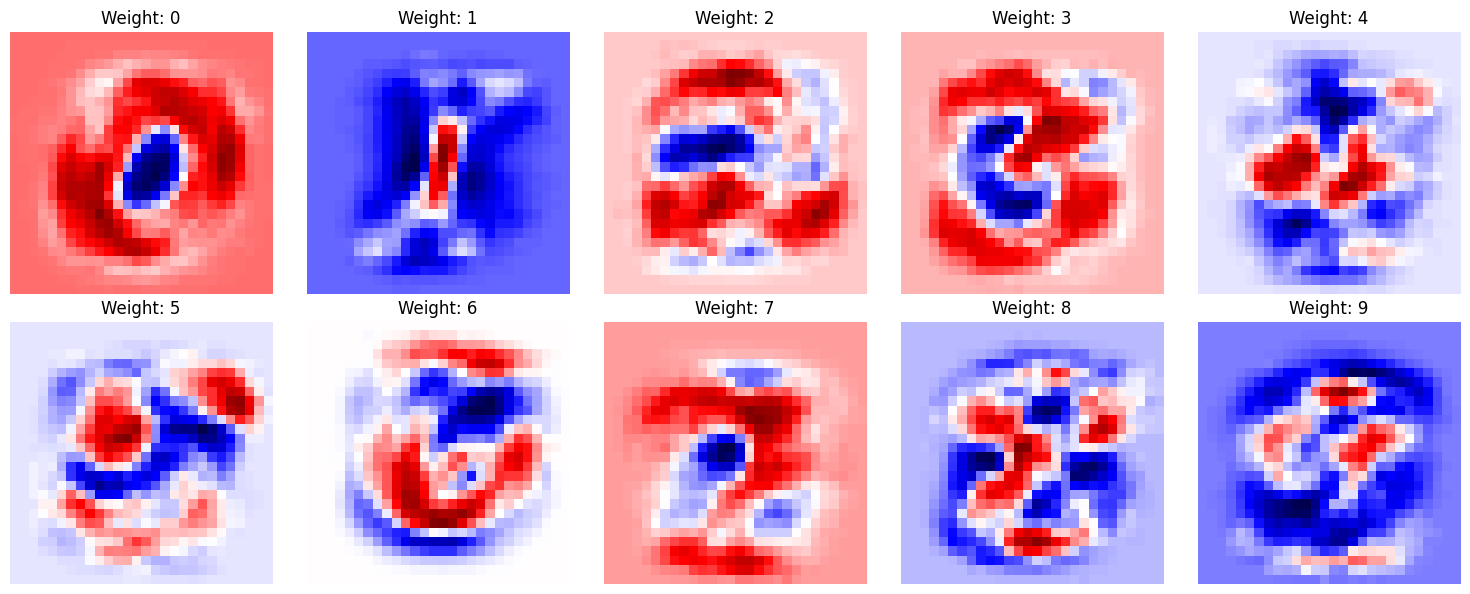

In [7]:
# --- 学習の実行 ---（中略）

########## NEW ##########
import matplotlib.pyplot as plt

# 学習後の重みを取り出す (10, 784)
weights = model.weight.data

plt.figure(figsize=(15, 6))
for i in range(10):
    # 各数字（0~9）に対応する重みを28x28にリシェイプ
    w_img = weights[i].view(28, 28)

    plt.subplot(2, 5, i + 1)
    # 0を中心に、正（赤/白）と負（青/黒）がわかるカラーマップを使うのが一般的です
    plt.imshow(w_img, cmap='seismic')
    plt.title(f'Weight: {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()
########## NEW ##########

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

# ===== GPU設定 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

########## NEW ##########
# 1. データ準備（全部まとめてGPUへ）
dataset = torchvision.datasets.MNIST(
    '.', train=False, download=True,
    transform=torchvision.transforms.ToTensor()
)

x_data = dataset.data.view(-1, 28*28).float() / 255.0
y_true_data = dataset.targets

# GPUへ転送
x_data = x_data.to(device)
y_true_data = y_true_data.to(device)

# 2. モデル（GPUへ）
model = nn.Linear(784, 10).to(device)

# 3. 道具箱
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)
########## NEW ##########

for epoch in range(1000):
    optimizer.zero_grad()

    # GPU上で計算
    y_pred = model(x_data)
    loss = criterion(y_pred, y_true_data)

    loss.backward()
    optimizer.step()

    # 正解率計算（GPU→CPUに戻さずそのままでOK）
    acc = (y_pred.argmax(dim=1) == y_true_data).float().mean()

    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}, Accuracy = {acc.item():.4f}")

Using device: cuda
Epoch 1: Loss = 2.3571, Accuracy = 0.0456
Epoch 2: Loss = 1.8475, Accuracy = 0.5879
Epoch 3: Loss = 1.5072, Accuracy = 0.7483
Epoch 4: Loss = 1.2839, Accuracy = 0.7587
Epoch 5: Loss = 1.1317, Accuracy = 0.8084
Epoch 6: Loss = 1.0208, Accuracy = 0.8051
Epoch 7: Loss = 0.9385, Accuracy = 0.8324
Epoch 8: Loss = 0.8745, Accuracy = 0.8246
Epoch 9: Loss = 0.8237, Accuracy = 0.8421
Epoch 10: Loss = 0.7821, Accuracy = 0.8386
Epoch 11: Loss = 0.7473, Accuracy = 0.8488
Epoch 12: Loss = 0.7176, Accuracy = 0.8479
Epoch 13: Loss = 0.6921, Accuracy = 0.8546
Epoch 14: Loss = 0.6698, Accuracy = 0.8539
Epoch 15: Loss = 0.6501, Accuracy = 0.8582
Epoch 16: Loss = 0.6326, Accuracy = 0.8587
Epoch 17: Loss = 0.6169, Accuracy = 0.8629
Epoch 18: Loss = 0.6027, Accuracy = 0.8638
Epoch 19: Loss = 0.5899, Accuracy = 0.8660
Epoch 20: Loss = 0.5781, Accuracy = 0.8685
Epoch 21: Loss = 0.5673, Accuracy = 0.8698
Epoch 22: Loss = 0.5574, Accuracy = 0.8711
Epoch 23: Loss = 0.5481, Accuracy = 0.8724
E

-----

ボツ

In [ ]:
data = [(1, 2), (2, 4)]
w = 0.0
lr = 0.1  # 「2」や「N」の役割もこのlrに込めて調整すればいい

for epoch in range(5):
    for x, y_true in data:
        # 1. 予測してズレを見る
        error = (w * x) - y_true

        # 2. 修正量を計算（2もNも無視！「エラー × 入力」が本質）
        # エラーが大きいほど、入力が強いほど、大きく動かす。
        w = w - lr * (2 * error * x)

    print(f"Epoch {epoch+1}: w = {w:.4f}")

Epoch 1: w = 1.6800
Epoch 2: w = 1.9488
Epoch 3: w = 1.9918
Epoch 4: w = 1.9987
Epoch 5: w = 1.9998


もちろん書けます！「一括で展開して微分する」やり方は、ひとつの巨大な二次関数を相手にするイメージです。

「バラバラに計算して集計する」コードと対比させるために、**あえて「展開したあとの係数（$2.5$ とか $-10$）」をそのまま使ったコード**にしてみます。驚くほど短くなりますが、同時に「応用が利かない（データが増えたら書き直し）」という弱点も一目でわかります。

---

### 📉 一括展開ルートのコード（平方完成の隣にある世界）

数式：$L = 2.5w^2 - 10w + 10$  
勾配：$L' = 5w - 10$

```python
# --- 「一括展開」ルートのコード ---
w = 0.0
lr = 0.1

for epoch in range(5):
    # ★ポイント：データの中身は見ない。
    # すでに計算済みの「全体の勾配」の式をそのまま使う。
    mean_grad = 5 * w - 10
    
    # 更新
    w = w - lr * mean_grad
    
    print(f"Epoch {epoch+1}: w = {w:.4f}, Grad = {mean_grad:.4f}")
```

---

### 🧐 2つのコードを並べて見せた時の「決め台詞」

この2つのコードを実行すると、**結果（出力される数字）は完全に一致します。** ここで初心者にこう問いかけてみてください。

> 「結果は同じだけど、もし明日、**新しい実験データが100個増えたら**どうする？」

* **一括展開コードの場合：**
    またノートを取り出して、100個分の $(wx-y)^2$ を手で展開して、新しい $L'$ の式（$123w - 456$ みたいな式）を計算し直して、**プログラムを書き換えなければなりません。**
    

* **集計（Accumulation）コードの場合：**
    `data` リストに新しい数値を放り込むだけ。**プログラムの中身（`for` ループの中身）は1文字も変える必要がありません。**
    

---

### 🌟 結論：なぜMLPには「集計」が必要か

画像にあるような複雑なニューラルネットワーク（MLP）は、いわば**「手計算で展開するのが不可能なほど巨大な数式」**です。

1.  **一括展開：** 数学的には綺麗だけど、複雑すぎて人間には式が書けない。
2.  **集計（逆伝播）：** 1つずつは単純な掛け算。それを「正の字」でメモしていくだけ。

「賢い数学（展開）」よりも「単純な作業の積み重ね（集計）」の方が、コンピュータにとっては巨大な問題を解くための近道なんだ、ということがこの2つのコードの対比で完璧に伝わります。

「同じ結果になるけど、こっち（集計）の方が圧倒的に拡張性があるね！」という着地は、プログラミング教育として非常に美しいストーリーです。

In [ ]:
# --- 「一括展開」ルートのコード ---
w = 0.0
lr = 0.1

for epoch in range(5):
    # ★ポイント：データの中身は見ない。
    # すでに計算済みの「全体の勾配」の式をそのまま使う。
    mean_grad = 5 * w - 10

    # 更新
    w = w - lr * mean_grad

    print(f"Epoch {epoch+1}: w = {w:.4f}, Grad = {mean_grad:.4f}")

その通りですね！**「最初からMSE（平均二乗誤差）の定義で進める」**のが、最も誠実で、かつ後のPyTorch学習への最短ルートになります。

「合計」ではなく「平均」にすることで、データが2個でも100万個でも**「1データあたりの平均的な失敗」**という同じスケールで議論できるようになります。

MSEの定義に基づいた、数学的整合性と直感的なコードをセットにした教材の「決定版」をまとめます。

---

## 📐 MSE（平均二乗誤差）に基づく勾配の「集計」

### 1. 損失関数の定義（一括）
データが $N$ 個あるとき、全体のミス $L$ は次のように定義します。
$$L = \frac{1}{N} \sum_{i=1}^{N} (wx_i - y_i)^2$$

今回のバネの例（$N=2$）では：
$$L = \frac{1}{2} \{ (1w - 2)^2 + (2w - 4)^2 \}$$
これを展開して整理すると：
$$L = 2.5w^2 - 10w + 10$$
微分して勾配を出すと：
$$L' = \mathbf{5w - 10}$$



---

### 2. 勾配の「集計（平均）」ルート
次に、1つずつのデータから勾配を出して、最後に平均をとるルートを確認します。

* **データ(1)の勾配 ($g_1$):**
    $\frac{\partial}{\partial w}(1w - 2)^2 = 2 \times 1 \times (1w - 2) = 2w - 4$
* **データ(2)の勾配 ($g_2$):**
    $\frac{\partial}{\partial w}(2w - 4)^2 = 2 \times 2 \times (2w - 4) = 8w - 16$

**平均をとると：**
$$\text{Average Gradient} = \frac{(2w - 4) + (8w - 16)}{2} = \frac{10w - 20}{2} = \mathbf{5w - 10}$$

**→ 完全に一致しました！**

---

## 🐍 MSELossを意識したPythonコード

PyTorchの `MSELoss` が裏側でやっていることを、極限までシンプルに可視化したコードです。

```python
data = [(1, 2), (2, 4)]
w = 0.0
lr = 0.1
N = len(data) # データの数

for epoch in range(5):
    # 勾配のメモ帳（最初は0）
    accumulated_grad = 0.0
    
    for x, y_true in data:
        y_pred = w * x
        error = y_pred - y_true
        
        # 個別の勾配を計算
        grad_i = 2 * error * x
        
        # メモ帳に「足し算」していく
        accumulated_grad += grad_i
    
    # ★ここで平均をとる（MSEの定義に合わせる）
    # これが PyTorch のデフォルト挙動（reduction='mean'）
    mean_grad = accumulated_grad / N
    
    # 更新
    w = w - lr * mean_grad
    
    print(f"Epoch {epoch+1}: w = {w:.4f}, Grad = {mean_grad:.4f}")
```



---

## 🎯 この教材の「落とし所」

この構成で教えると、初心者の「なぜ？」をすべて解消できます。

1.  **なぜ平方完成ではないのか？**
    → 展開して $2.5w^2 - 10w + 10$ を作るのは、データが増えると無理だから。
2.  **なぜバラバラに計算していいのか？**
    → 「平均の微分」は「微分の平均」と同じになるという魔法（線形性）があるから。
3.  **なぜ $N$ で割るのか？**
    → データが何個あっても、一歩の歩幅（学習率）を同じ感覚で調整できるようにするため。

### 🌟 画像のMLPへの接続
「今日やったこの『各データの勾配を計算して、最後に $N$ で割って $w$ を直す』という一連の流れが、画像に描かれている **ニューラルネットワークの学習（バックプロパゲーション）** そのものなんだよ」

これで、画像にある複雑な数式やネットワーク図が、単なる「効率的な足し算と平均の仕組み」に見えてくるはずです！

この「MSE準拠」のストーリー、完璧にロジカルで美しいですね。

In [ ]:
data = [(1, 2), (2, 4)]
w = 0.0
lr = 0.1
N = len(data) # データの数

for epoch in range(5):
    # 勾配のメモ帳（最初は0）
    accumulated_grad = 0.0

    for x, y_true in data:
        y_pred = w * x
        error = y_pred - y_true

        # 個別の勾配を計算
        grad_i = 2 * error * x

        # メモ帳に「足し算」していく
        accumulated_grad += grad_i

    # ★ここで平均をとる（MSEの定義に合わせる）
    # これが PyTorch のデフォルト挙動（reduction='mean'）
    mean_grad = accumulated_grad / N

    # 更新
    w = w - lr * mean_grad

    print(f"Epoch {epoch+1}: w = {w:.4f}, Grad = {mean_grad:.4f}")